![TensorFlow](https://upload.wikimedia.org/wikipedia/commons/thumb/a/ab/TensorFlow_logo.svg/960px-TensorFlow_logo.svg.png)


In [1]:
import tensorflow as tf
import keras as K
import numpy as np

In [2]:
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {K.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


# Tensor Manipulation Basics

### Tensor Creation

A 0-dimensional tensor is a __scalar__

In [3]:
scalar = tf.constant(0)
print(f"Value of the tensor = {scalar}")
print(f"Number of dimensions = {len(scalar.shape)}")
print(f"Tensor's shape = {scalar.shape}")

Value of the tensor = 0
Number of dimensions = 0
Tensor's shape = ()


A 1-dimensional tensor is a __vector__

In [4]:
vector = tf.constant([1, 2, 3])
print(f"Value of the tensor = {vector}")
print(f"Number of dimensions = {len(vector.shape)}")
print(f"Tensor's shape = {vector.shape}")

Value of the tensor = [1 2 3]
Number of dimensions = 1
Tensor's shape = (3,)


A 2-dimensional tensor is a __matrix__

In [5]:
matrix = tf.constant(
    [[1, 2, 3],
     [4, 5, 6],
     [7, 8, 9]]
)
print(f"Value of the tensor = \n {matrix}")
print(f"Number of dimensions = {len(matrix.shape)}")
print(f"Tensor's shape = {matrix.shape}")

Value of the tensor = 
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Number of dimensions = 2
Tensor's shape = (3, 3)


We can generalize tensors to __n dimensions__

In [6]:
n = 3
tensor = tf.random.normal(tuple(3 for _ in range(n)))
print(f"Value of the tensor = \n {tensor}")
print(f"Number of dimensions = {len(tensor.shape)}")
print(f"Tensor's shape = {tensor.shape}")

Value of the tensor = 
 [[[ 1.0054324  -1.8768635   0.4607092 ]
  [-0.50437826 -1.9843818   0.27455103]
  [-1.4735163  -0.42054287  0.17830992]]

 [[ 1.4853534  -0.67678964 -0.21407464]
  [-1.0962384   0.9207932  -0.09947366]
  [-0.6685169   1.6236892   0.50349545]]

 [[ 2.037328    1.0003464  -2.033675  ]
  [ 1.5409182   0.8250645   0.88734114]
  [ 1.3319584   0.53447413 -0.2322756 ]]]
Number of dimensions = 3
Tensor's shape = (3, 3, 3)


Each tensor is characterized also by a __data type__

In [7]:
tensor.dtype

tf.float32

Which can be cast to others (with the clear consequences on the numerical representation)

In [8]:
int_tensor = tf.cast(tensor, dtype=tf.int32)
print(int_tensor)

tf.Tensor(
[[[ 1 -1  0]
  [ 0 -1  0]
  [-1  0  0]]

 [[ 1  0  0]
  [-1  0  0]
  [ 0  1  0]]

 [[ 2  1 -2]
  [ 1  0  0]
  [ 1  0  0]]], shape=(3, 3, 3), dtype=int32)


### Tensor indexing and slicing

Tensors can be __indexed__ (i.e., ``tensor[i, :, :]``) or __sliced__ (i.e., ``tensor[:i, ...]``).

Indexing a tensor reduces its dimensionality depending to the number of "free" dimensions.

In [9]:
print(f"Scalar = {tensor[0, 1, 0]}")
print(f"Vector = {tensor[:, 0, -1]}") # : means all elements in that dimension
print(f"Matrix = {tensor[:, 2]}")

Scalar = -0.5043782591819763
Vector = [ 0.4607092  -0.21407464 -2.033675  ]
Matrix = [[-1.4735163  -0.42054287  0.17830992]
 [-0.6685169   1.6236892   0.50349545]
 [ 1.3319584   0.53447413 -0.2322756 ]]


Slicing reduces the size of the sliced dimension. With this approach, only contiguous slices can be taken. To get scattered slices, use [``tf.gather``](https://www.tensorflow.org/api_docs/python/tf/gather).

In [10]:
tensor_slice = tensor[1:]
print(f"tensor_slice = {tensor_slice}")
print(f"Shape of tensor_slice = {tensor_slice.shape}")
print(f"Number of dimensions = {len(tensor_slice.shape)}")

tensor_slice = [[[ 1.4853534  -0.67678964 -0.21407464]
  [-1.0962384   0.9207932  -0.09947366]
  [-0.6685169   1.6236892   0.50349545]]

 [[ 2.037328    1.0003464  -2.033675  ]
  [ 1.5409182   0.8250645   0.88734114]
  [ 1.3319584   0.53447413 -0.2322756 ]]]
Shape of tensor_slice = (2, 3, 3)
Number of dimensions = 3


In [11]:
tensor_slice = tensor[1:, :, -1:]
print(f"tensor_slice = {tensor_slice}")
print(f"Shape of tensor_slice = {tensor_slice.shape}")
print(f"Number of dimensions = {len(tensor_slice.shape)}")

tensor_slice = [[[-0.21407464]
  [-0.09947366]
  [ 0.50349545]]

 [[-2.033675  ]
  [ 0.88734114]
  [-0.2322756 ]]]
Shape of tensor_slice = (2, 3, 1)
Number of dimensions = 3


Indexing and slicing can be also mixed.

In [12]:
tensor_slice = tensor[1:, :, 2]
print(f"tensor_slice = {tensor_slice}")
print(f"Shape of tensor_slice = {tensor_slice.shape}")
print(f"Number of dimensions = {len(tensor_slice.shape)}")

tensor_slice = [[-0.21407464 -0.09947366  0.50349545]
 [-2.033675    0.88734114 -0.2322756 ]]
Shape of tensor_slice = (2, 3)
Number of dimensions = 2


### Concat and stack

- ``tf.concat``: concatenates n tensors on the `axis` dimension. All the dimensions of the input tensors, except for the `axis` dimension, must match.
- ``tf.stack``: stacks n tensors on the `axis` dimension, which is added for the resulting tensor. All the dimensions of the input tensors must match.

In [13]:
tensor_1 = tf.random.normal((2, 3, 4))
tensor_2 = tf.random.uniform((2, 6, 4))
concat_tensor = tf.concat([tensor_1, tensor_2], axis=1)
print(f"Shape = {concat_tensor.shape}")

Shape = (2, 9, 4)


In [14]:
tensor_2 = tf.random.uniform((2, 3, 4))
stacked_tensor = tf.stack([tensor_1, tensor_2], axis=1)
print(f"Shape = {stacked_tensor.shape}")

Shape = (2, 2, 3, 4)


### Coming from PyTorch

TensorFlow and PyTorch share the same NumPy-inspired semantics for tensor manipulation, but there are a few differences worth noting.

#### Mutability

In PyTorch every tensor is **mutable** — you can modify it in-place with operators that have a trailing `_` (e.g. `add_`, `mul_`). In TensorFlow, `tf.constant` produces an **immutable** tensor. If you need mutable state (e.g. model parameters), you must use `tf.Variable`.

In [15]:
import torch

# PyTorch: tensors are mutable
pt = torch.tensor([1.0, 2.0, 3.0])
pt.add_(10)          # in-place: pt is now [11, 12, 13]
pt[0] = 0.0          # item assignment works
print("PyTorch after in-place ops:", pt)

PyTorch after in-place ops: tensor([ 0., 12., 13.])


In [16]:
# TensorFlow: tf.constant is immutable
tc = tf.constant([1.0, 2.0, 3.0])
# tc[0].assign(0.0)  # AttributeError — constants have no .assign()
# There is no add_() either; every operation returns a *new* tensor
tc2 = tc + 10
print("Original constant:", tc)
print("New tensor after +10:", tc2)

Original constant: tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32)
New tensor after +10: tf.Tensor([11. 12. 13.], shape=(3,), dtype=float32)


In [17]:
try:
    tc[0] = 0.0
except TypeError as e:
    print(e)

'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment


In [18]:
# TensorFlow: tf.Variable is mutable
tv = tf.Variable([1.0, 2.0, 3.0])
tv.assign_add([10, 10, 10])   # in-place add
tv[0].assign(0.0)             # item assignment works
print("Variable after in-place ops:", tv)

Variable after in-place ops: <tf.Variable 'Variable:0' shape=(3,) dtype=float32, numpy=array([ 0., 12., 13.], dtype=float32)>


#### Type strictness

PyTorch **auto-promotes** dtypes: mixing `int` and `float` tensors silently produces a `float` result. TensorFlow is **strict** — operands must have matching dtypes or you get an error. You must cast explicitly with `tf.cast`.

In [19]:
# PyTorch: implicit promotion
a_pt = torch.tensor([1, 2, 3])          # int64
b_pt = torch.tensor([0.1, 0.2, 0.3])    # float32
print("PyTorch int + float =", a_pt + b_pt)  # works, result is float32

PyTorch int + float = tensor([1.1000, 2.2000, 3.3000])


In [20]:
# TensorFlow: strict dtype matching
a_tf = tf.constant([1, 2, 3])            # int32
b_tf = tf.constant([0.1, 0.2, 0.3])      # float32
try:
    a_tf + b_tf  # TypeError!
except (TypeError, tf.errors.InvalidArgumentError) as e:
    print(f"TF error: {e}")

# Fix: explicit cast
print("After tf.cast:", tf.cast(a_tf, tf.float32) + b_tf)

TF error: cannot compute AddV2 as input #1(zero-based) was expected to be a int32 tensor but is a float tensor [Op:AddV2] name: 
After tf.cast: tf.Tensor([1.1 2.2 3.3], shape=(3,), dtype=float32)


#### Reshaping and memory layout

In PyTorch, `view` and `reshape` behave differently:
- `view` **requires contiguous memory** — it fails on tensors whose memory layout was broken by `transpose` or `permute`;
- `reshape` **always works** — it returns a view when possible, or silently copies the data otherwise.

TensorFlow has **only `tf.reshape`**, and it behaves like PyTorch's `reshape`: it always succeeds. However, there is an important difference: since TF tensors are immutable, the framework is free to decide internally whether to share or copy the underlying buffer — the user cannot observe the difference. There is no `view` equivalent and no notion of contiguity exposed to the user.

In [21]:
# PyTorch: view vs reshape after transpose
x_pt = torch.arange(6).reshape(2, 3)
print("Original:\n", x_pt)

xt_pt = x_pt.t()  # transpose — makes the tensor non-contiguous
print(f"\nTransposed (contiguous? {xt_pt.is_contiguous()}):\n", xt_pt)

try:
    xt_pt.view(6)  # fails: non-contiguous!
except RuntimeError as e:
    print(f"\nview error: {e}")

print("reshape works:", xt_pt.reshape(6))           # silently copies
print("contiguous().view works:", xt_pt.contiguous().view(6))  # explicit copy then view

Original:
 tensor([[0, 1, 2],
        [3, 4, 5]])

Transposed (contiguous? False):
 tensor([[0, 3],
        [1, 4],
        [2, 5]])

view error: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.
reshape works: tensor([0, 3, 1, 4, 2, 5])
contiguous().view works: tensor([0, 3, 1, 4, 2, 5])


In [22]:
# TensorFlow: tf.reshape always succeeds — no contiguity concept
x_tf = tf.constant([[0, 1, 2], [3, 4, 5]])
print("Original:\n", x_tf)

xt_tf = tf.transpose(x_tf)
print("\nTransposed:\n", xt_tf)

flat_tf = tf.reshape(xt_tf, [-1])  # always works
print("\nReshaped (flat):", flat_tf)

Original:
 tf.Tensor(
[[0 1 2]
 [3 4 5]], shape=(2, 3), dtype=int32)

Transposed:
 tf.Tensor(
[[0 3]
 [1 4]
 [2 5]], shape=(3, 2), dtype=int32)

Reshaped (flat): tf.Tensor([0 3 1 4 2 5], shape=(6,), dtype=int32)


Notice the **element order** in the flattened tensors above: both PyTorch's `reshape` and TensorFlow's `tf.reshape` read elements in **row-major (C) order from the current logical layout**. After a transpose the logical layout changes, so flattening a transposed tensor gives `[0, 3, 1, 4, 2, 5]` (columns of the original), not `[0, 1, 2, 3, 4, 5]`.

---
# Keras Basics

Keras is a high-level library leveraging TensorFlow as backend. It allows to build and experiment with ML models with an easy and flexible interface.

API Docs (go to `tf.keras`): https://www.tensorflow.org/versions

Keras Guides (for specific API components): https://www.tensorflow.org/guide/keras

Tutorials (cover examples of basic usage): https://www.tensorflow.org/tutorials/keras

**Warning:** in general, it is better to use Keras whenever it is possible, since it exploits compiled computational graphs, making it way more efficent than TensorFlow (with eager execution activated, which is the default behaviour).

In [23]:
import seaborn as sns
import pandas as pd
sns.set_theme()

In [24]:
from sklearn.model_selection import train_test_split

(train_X, train_y), (test_X, test_y) = K.datasets.mnist.load_data(path='ds')
train_X, eval_X, train_y, eval_y = train_test_split(
    train_X, train_y,
    test_size=0.15,
    shuffle=True,
    stratify=train_y
)

# Model Interfaces in Keras

Now we will see how to solve the same problem we've seen before with these three interfaces.

## Sequential API

Everything is wrapped within the ``K.Sequential()`` "box", and all the objects that you add to this box are considered layers. Note that, here, a layer is not necessarily a neural layer, but whatever applies a transformation to the output of the previous layer (or to the input data).

In general, you can consider the K.Sequential() interface as a wrapper for the pipeline which applies all the subsequent transformations to your input data, ending to the prediction of your model.

In [25]:
seq_model = K.Sequential()

seq_model.add(K.Input(shape=(28, 28))) # What happens if I remove the input?
seq_model.add(K.layers.Flatten())
seq_model.add(K.layers.Rescaling(scale=1./255))
seq_model.add(K.layers.Dense(10, activation='softmax'))
seq_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

### Functional API

In the Functional API, you explicitly create the pipeline we discussed before by performing subsequent applications of all the functions, __starting from a placeholder defining the input tensor__.

In [26]:
inputs = K.Input(shape=(28, 28)) # Implicitly, the shape will be (None, 28, 28)
flattened = K.layers.Flatten()(inputs)
rescaled = K.layers.Rescaling(scale=1/255.)(flattened)
outputs = K.layers.Dense(units=10, activation='softmax')(rescaled)
fn_model = K.Model(inputs=inputs, outputs=outputs)
fn_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

## K.Model API

This is the best chance you have to exploit the synergy between Keras and TensorFlow. You can define your own custom model by inheriting from the class ``K.Model``.

In [27]:
@K.saving.register_keras_serializable()
class SimpleLinearClassifier(K.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.flatten = K.layers.Flatten()
        self.rescale = K.layers.Rescaling(scale=1./255)
        self.dense = K.layers.Dense(units=10, activation='softmax')

    def call(self, inputs):
        x = self.flatten(inputs)
        x = self.rescale(x)
        return self.dense(x)

cl_model = SimpleLinearClassifier()
cl_model.summary()

Model: "simple_linear_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Compiling the pipeline

As mentioned at the beginning, the greatest advantage of Keras over TensorFlow is that our processing pipeline is compiled on a static computational graph.

In [28]:
#model = seq_model
#model = fn_model
model = cl_model

In [29]:
model.compile(
    optimizer=K.optimizers.Adam(learning_rate=0.1),
    loss=K.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Model Training

Training a model with Keras is as simple as calling the `.fit` method.

The ``callbacks`` parameter allows to add a list of functionalities which are called at specific times of the training loop.

In [30]:
early_stopping = K.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    min_delta=0.0005,
    restore_best_weights=True
)

In [31]:
history = model.fit(
    x=train_X,
    y=train_y,
    epochs=100,
    batch_size=1000,
    validation_data=(eval_X, eval_y),
    callbacks=[early_stopping]
)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8485 - loss: 0.7122 - val_accuracy: 0.9043 - val_loss: 0.4563
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9178 - loss: 0.3386 - val_accuracy: 0.9122 - val_loss: 0.3540
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9181 - loss: 0.2999 - val_accuracy: 0.9084 - val_loss: 0.3655
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9168 - loss: 0.3021 - val_accuracy: 0.9007 - val_loss: 0.3768
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9153 - loss: 0.3075 - val_accuracy: 0.9028 - val_loss: 0.3901
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9192 - loss: 0.3023 - val_accuracy: 0.9073 - val_loss: 0.3800
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9208 - loss: 0.2929 - val_accuracy: 0.9017 - val_loss: 0.4071


And we have the additional advantage of the training history, providing statistics of the training phase useful for observing the behaviour of the model when the process is over.

In [32]:
list(history.history)

['accuracy', 'loss', 'val_accuracy', 'val_loss']

[Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss value')]

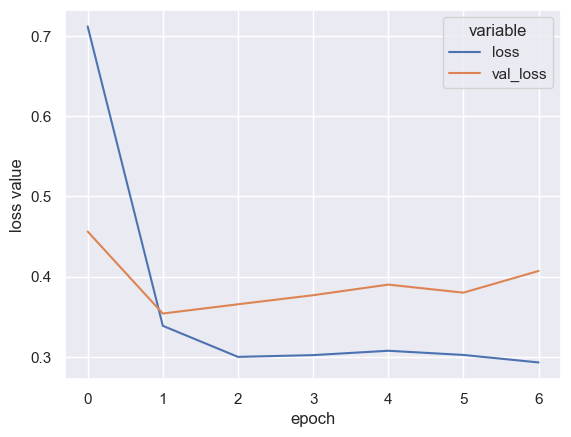

In [33]:
results = pd.DataFrame({
    'epoch': history.epoch,
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss']
})
ax = sns.lineplot(x='epoch', y='value', hue='variable', data=pd.melt(results, ['epoch']))
ax.set(xlabel='epoch', ylabel='loss value')

[Text(0.5, 0, 'epoch'), Text(0, 0.5, 'accuracy value')]

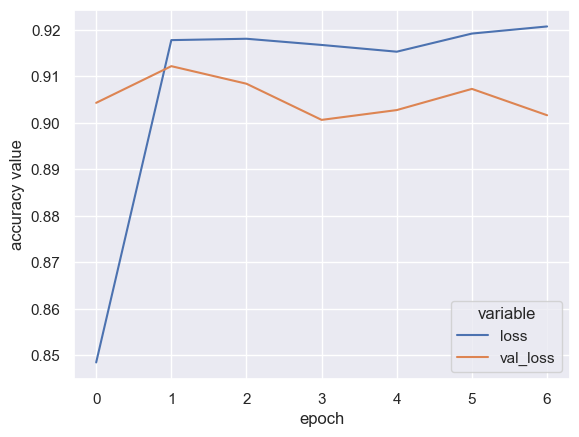

In [34]:
results = pd.DataFrame({
    'epoch': history.epoch,
    'loss': history.history['accuracy'],
    'val_loss': history.history['val_accuracy']
})
ax = sns.lineplot(x='epoch', y='value', hue='variable', data=pd.melt(results, ['epoch']))
ax.set(xlabel='epoch', ylabel='accuracy value')

Keras models expose the method `.evaluate`, which returns the results of the metrics on a given dataset.

In [35]:
metrics = model.evaluate(test_X, test_y)
metrics # loss, accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9179 - loss: 0.3277


[0.3277198076248169, 0.917900025844574]

Instead, `.predict` returns the predictions of the model

In [36]:
predictions = model.predict(test_X)
predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[7.7205914e-10, 1.7876806e-16, 1.2226607e-07, ..., 9.9940729e-01,
        1.5201326e-06, 3.8577939e-05],
       [7.9284894e-07, 6.1436793e-08, 9.9956149e-01, ..., 1.6784189e-24,
        1.9180325e-05, 1.4238406e-18],
       [6.4991039e-09, 9.6818101e-01, 2.3084234e-02, ..., 3.7954160e-04,
        5.4221693e-03, 5.4486311e-05],
       ...,
       [4.4982474e-14, 1.4942362e-12, 3.8958106e-08, ..., 1.6845574e-04,
        4.2877175e-04, 2.2621923e-03],
       [6.1773861e-13, 1.4269644e-10, 6.2480278e-11, ..., 3.8119997e-11,
        9.0852985e-03, 3.7423653e-10],
       [4.6274037e-11, 4.9760320e-24, 1.3112721e-08, ..., 1.1934497e-18,
        8.0520923e-11, 6.5287526e-17]], shape=(10000, 10), dtype=float32)

## Model serialization

A Keras Model can be easily `serialized` and `deserialized` as follows.

**Note:** custom `K.Model` subclasses must be decorated with `@K.saving.register_keras_serializable()` so that Keras can locate the class when loading the model back. Without it, `load_model` fails with a `TypeError`. The Sequential and Functional APIs do not need this because they are built from standard Keras layers that are already registered.

In [37]:
model.save('my_model.keras', overwrite=True)

In [38]:
loaded_model = K.models.load_model('my_model.keras')

There are several other options to serialize a model. It can be saved in H5 format, you can save only the parameters, only the model architecture etc..
You can find further details at the following webpage: https://www.tensorflow.org/guide/keras/save_and_serialize

In [39]:
loaded_model.summary()

Model: "simple_linear_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (1000, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (1000, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1000, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,552 (92.00 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,702 (61.34 KB)

---
## Your Turn! — MNIST CNN

Implement and train a **Convolutional Neural Network** to perform image classification on the MNIST dataset.

In [42]:
from keras.datasets import mnist
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical


# Load MNIST
(mnist_train_X, mnist_train_y), (mnist_test_X, mnist_test_y) = mnist.load_data(path='ds')


# Split mnist_train into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    mnist_train_X,
    mnist_train_y,
    test_size=0.2,
    random_state=42,
    stratify=mnist_train_y
)


# Rescale and reshape the data for a CNN
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = mnist_test_X.astype("float32") / 255.0

# Add channel dimension: (28, 28) -> (28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_val = X_val.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(mnist_test_y, 10)

In [44]:
# Define your CNN model
mnist_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

In [46]:
# Compile the model
mnist_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# Train the model with early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = mnist_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    callbacks=[early_stopping]
)


# Evaluate on the test set
test_loss, test_accuracy = mnist_model.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9765 - loss: 0.0775 - val_accuracy: 0.9851 - val_loss: 0.0487
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9833 - loss: 0.0550 - val_accuracy: 0.9873 - val_loss: 0.0410
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9859 - loss: 0.0461 - val_accuracy: 0.9893 - val_loss: 0.0373
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9880 - loss: 0.0388 - val_accuracy: 0.9887 - val_loss: 0.0362
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9893 - loss: 0.0343 - val_accuracy: 0.9893 - val_loss: 0.0363
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9908 - loss: 0.0282
Test loss: 0.028160998597741127
Test accuracy: 0.9908000230789185
